# 01 — Demand Patterns
**Question:** When is demand highest, and how do weekday vs weekend patterns differ?

Data source: `mart_station_demand` and `fact_rentals` in `m2-dataset-study.london_bicycles`

In [11]:
# only needed if you want to run the example code in this directory
# only once, to install the dependencies

# pip install google-cloud-bigquery sqlalchemy-bigquery db-dtypes

In [12]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PROJECT = 'm2-dataset-study'
DATASET = 'london_bicycles'

client = bigquery.Client(project=PROJECT)

def bq(sql):
    return client.query(sql, location='EU').to_dataframe()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.titlesize'] = 28
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['axes.titlepad'] = 20

## 1.1 — Hourly demand heatmap (weekday vs weekend)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


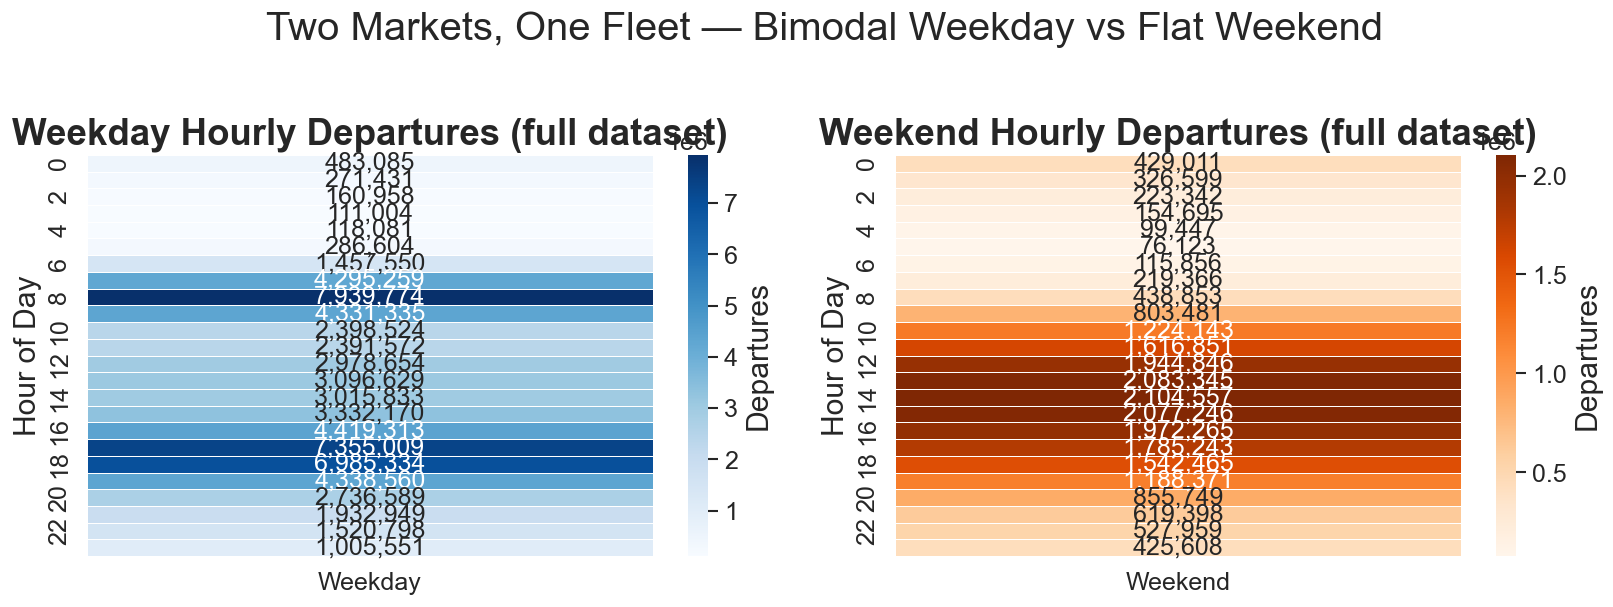

In [13]:
sql = """
SELECT
    hour_of_day,
    day_type,
    SUM(departures) AS total_departures
FROM `m2-dataset-study.london_bicycles_dev_marts.mart_station_demand`
GROUP BY hour_of_day, day_type
"""
df = bq(sql)
pivot = df.pivot(index='hour_of_day', columns='day_type', values='total_departures')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cmap in zip(axes, ['Weekday', 'Weekend'], ['Blues', 'Oranges']):
    vals = pivot[[col]]
    sns.heatmap(vals, ax=ax, cmap=cmap, fmt=',', annot=True, annot_kws={'size': 15},
                linewidths=0.5, cbar_kws={'label': 'Departures'})
    ax.set_title(f'{col} Hourly Departures (full dataset)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Hour of Day', fontsize=18)
    ax.set_xlabel('')

plt.suptitle('Two Markets, One Fleet — Bimodal Weekday vs Flat Weekend', fontsize=28, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_demand_heatmap.png', bbox_inches='tight')
plt.show()

## 1.2 — Peak hour comparison chart

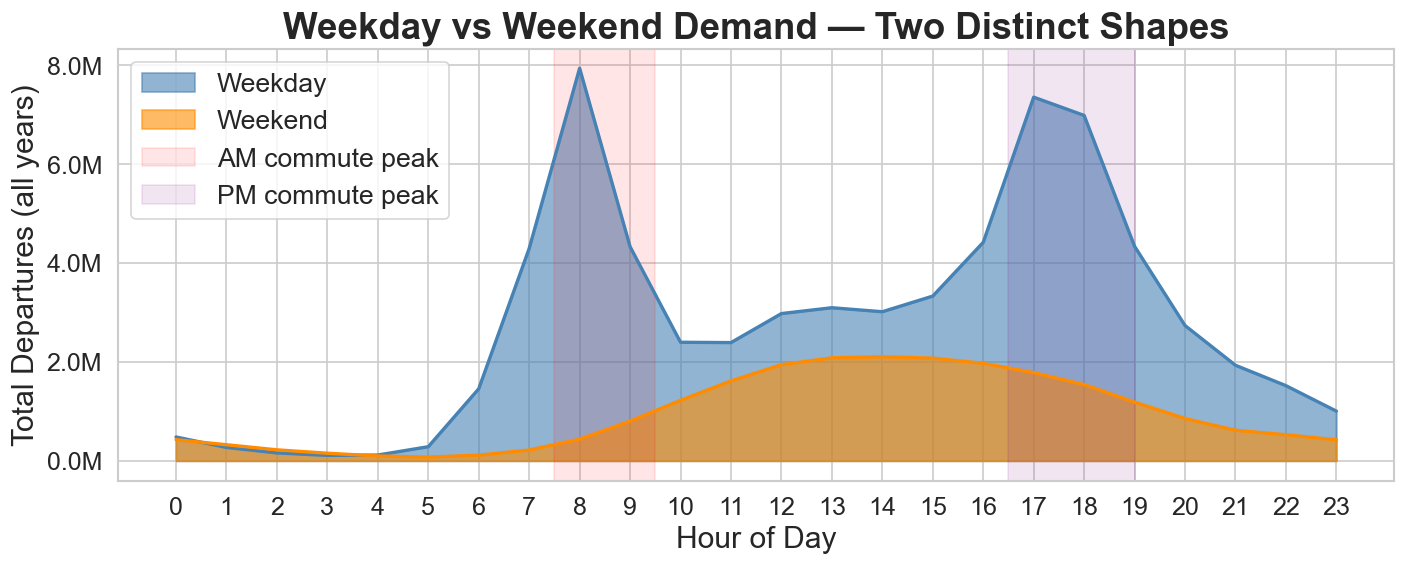

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
hours = range(24)
weekday = pivot.get('Weekday', pd.Series(0, index=range(24)))
weekend = pivot.get('Weekend', pd.Series(0, index=range(24)))

ax.fill_between(hours, weekday, alpha=0.6, color='steelblue', label='Weekday')
ax.fill_between(hours, weekend, alpha=0.6, color='darkorange', label='Weekend')
ax.plot(hours, weekday, color='steelblue', linewidth=2)
ax.plot(hours, weekend, color='darkorange', linewidth=2)

ax.axvspan(7.5, 9.5, alpha=0.1, color='red', label='AM commute peak')
ax.axvspan(16.5, 19.0, alpha=0.1, color='purple', label='PM commute peak')

ax.set_xticks(range(24))
ax.set_xlabel('Hour of Day', fontsize=18)
ax.set_ylabel('Total Departures (all years)', fontsize=18)
ax.set_title('Weekday vs Weekend Demand — Two Distinct Shapes', fontsize=24, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/01_peak_comparison.png', bbox_inches='tight')
plt.show()

## 1.3 — Trip segment breakdown

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


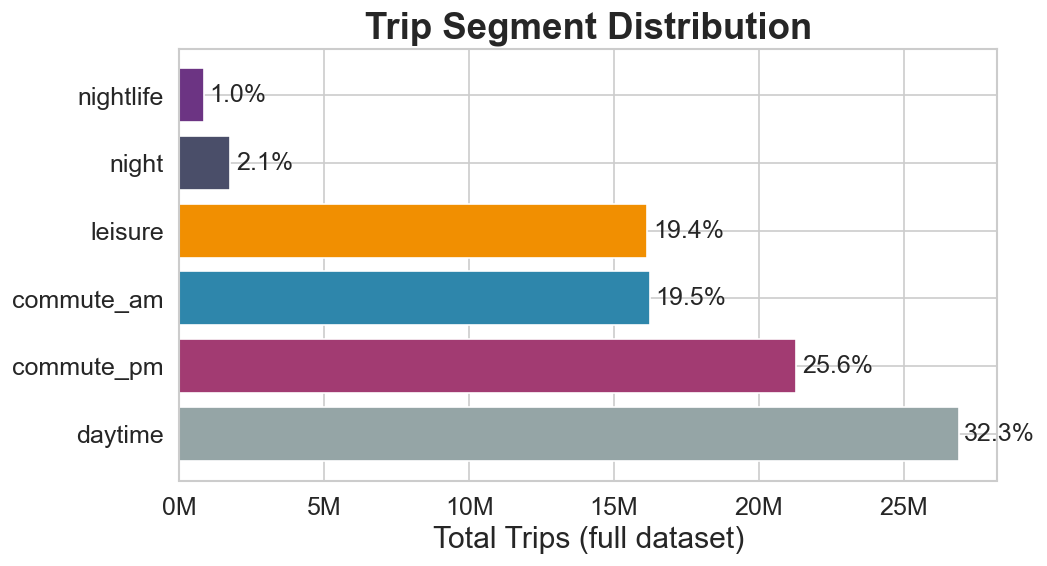

trip_segment  trip_count  pct
     daytime    26888873 32.3
  commute_pm    21286233 25.6
  commute_am    16224912 19.5
     leisure    16147721 19.4
       night     1758693  2.1
   nightlife      833580  1.0


In [15]:
seg_sql = """
SELECT
    trip_segment,
    COUNT(*) AS trip_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
FROM `m2-dataset-study.london_bicycles_dev_facts.fact_rentals`
GROUP BY trip_segment
ORDER BY trip_count DESC
"""
seg = bq(seg_sql)

colours = {'commute_am': '#2E86AB', 'commute_pm': '#A23B72',
           'leisure': '#F18F01', 'nightlife': '#6C3483',
           'night': '#4A4E69', 'daytime': '#95A5A6'}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(seg['trip_segment'], seg['trip_count'],
               color=[colours.get(s, '#888') for s in seg['trip_segment']])
for bar, pct in zip(bars, seg['pct']):
    ax.text(bar.get_width() + 2e5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_xlabel('Total Trips (full dataset)', fontsize=18)
ax.set_title('Trip Segment Distribution', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_segment_breakdown.png', bbox_inches='tight')
plt.show()
print(seg.to_string(index=False))